In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import linear_model
from collections import OrderedDict

from torch.utils.data import Dataset
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
NUM_SEEDS = 5
FEATURES = ('linear','xor_xor_xor')

TRAIN_DATASET_SIZE = 8192
TEST_DATASET_SIZE = 1024

BATCH_SIZE = 1024

OP_FNS = {'and': np.logical_and, 'or': np.logical_or, 'xor': np.logical_xor}

# Data

In [5]:
def make_dataset(features=FEATURES, input_unit_size=16, num_samples=126, seed=123):
    np.random.seed(seed)
    inputs = np.random.binomial(1, 0.5, size=(num_samples, len(features)*input_unit_size))
    outputs = []

    for feature_i, feature_type in enumerate(features):
        input_unit = inputs[:, feature_i*input_unit_size:(feature_i+1)*input_unit_size]

        if feature_type == 'linear':
            input_unit[:, :4] =  input_unit[:, :1]
            output_unit = input_unit[:, :1]
        else:
            output_unit = np.zeros_like(input_unit[:, :1])
            def feature_val(input):
                top, left, right = [OP_FNS[op] for op in feature_type.split('_')]
                return top(left(input[0], input[1]), right(input[2], input[3]))

            for number, index in enumerate(np.random.permutation(num_samples)):
                while feature_val(input_unit[index]) != number % 2:
                    input_unit[index] = np.random.binomial(1,0.5, input_unit_size)
                output_unit[index] = feature_val(input_unit[index])

        outputs.append(output_unit)

    return {'inputs': inputs, 'labels': np.concatenate(outputs, axis=-1)}


In [6]:
class Data(Dataset):
    def __init__(self, inputs, labels):
        self.data = inputs.astype(np.float32)
        self.target = labels.astype(np.float32)

    def __getitem__(self, index):
        x = self.data[index]
        y = self.target[index]

        return (x,y)

    def __len__(self):
        return len(self.data)

# Model

In [7]:
# initialize weights like flax??
class MLP(nn.Module):
    def __init__(self, layer_sizes: list[int]):
        super(MLP, self).__init__()
        self.layer_sizes = layer_sizes
        layers = []
        for i in range(len(layer_sizes)-2):
            layers.append((f'linear_{i}',nn.Linear(layer_sizes[i],layer_sizes[i+1])))
            layers.append((f'leaky_relu_{i}',nn.LeakyReLU()))
        self.model_body = nn.Sequential(OrderedDict(layers))
        self.output = nn.Linear(layer_sizes[-2], layer_sizes[-1])

    def forward(self, x):
        x = self.model_body(x)
        out = self.output(x)
        return out, x

# Analysis

In [8]:
def rsm(test_reps):
    rsm = np.zeros((len(test_reps), len(test_reps)))
    for i, d1 in enumerate(test_reps):
        for j, d2 in enumerate(test_reps):
            rsm[i, j] = np.linalg.norm(d1-d2)
    return rsm
    # get output for each sample input
    # matrix of euclidean distance of outputs
    # pearson correlation between rsms

In [9]:
def analyze_rep_var_explained(fit_reps, fit_labels, test_reps, test_labels):
    scores = []
    total_var = np.sum(np.var(test_reps,axis=0))

    for feat in range(fit_labels.shape[-1]):
        regr = linear_model.LinearRegression()
        regr.fit(fit_labels[:, feat:feat+1], fit_reps)
        scores.append(regr.score(test_labels[:, feat:feat+1], test_reps))

    return scores, total_var

In [10]:
def pred(loader,model):
    model.eval()
    ys =[]
    rs = []
    with (torch.no_grad()):
        for X ,y in loader:
            #X=X.to(torch.device('mps'))
            #y=y.to(torch.device('mps'))
            y_pred, reps = model(X)

            outs = ((y_pred>0) == y).float()
            outs = outs.mean().item()
            ys.append(outs)
            rs.append(reps)
    model.train()
    o=(*ys,)

    return np.mean(ys), rs[0]


# Training

In [11]:
def train_epoch(model, train_loader, criterion,optimizer):
    '''
    for each epoch
        iterate over batches updating model
    '''
    total_loss = 0 # should it be mean or sum??
    for batch_data in train_loader:
        #device = torch.device('mps' if torch.mps.is_available() else 'cpu')

        inputs, labels = batch_data

        #inputs = inputs.to(device)
        #labels = labels.to(device)


        outputs, _ = model(inputs)

        loss = criterion(outputs, labels)
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    return total_loss
    # want to track loss, accuracies, feature losses, penultimate_reps

In [12]:
# write results to csv file

def run(features=FEATURES, units_per_feature=16, verbose=0,n=2):
    rvs = []
    model=None
    for seed in range(NUM_SEEDS):
        torch.manual_seed(123+seed)

        #device = torch.device('mps' if torch.mps.is_available() else 'cpu')

        train_data = make_dataset(features=features, num_samples=TRAIN_DATASET_SIZE, input_unit_size=units_per_feature, seed=123+seed)
        val_data = make_dataset(features=features, num_samples=TEST_DATASET_SIZE, input_unit_size=units_per_feature, seed=1234+seed)
        test_data = make_dataset(features=features, num_samples=TEST_DATASET_SIZE, input_unit_size=units_per_feature, seed=12345+seed)

        train_loader = torch.utils.data.DataLoader(Data(train_data['inputs'],train_data['labels']), batch_size=BATCH_SIZE, shuffle=True, )
        val_loader = torch.utils.data.DataLoader(Data(val_data['inputs'],val_data['labels']), batch_size=BATCH_SIZE, shuffle=False)
        test_loader = torch.utils.data.DataLoader(Data(test_data['inputs'],test_data['labels']), batch_size=BATCH_SIZE, shuffle=False)

        layer_sizes = [units_per_feature*len(features), 256, 128, 64, 64, len(features)]
        model = MLP(layer_sizes=layer_sizes)

        criterion = nn.BCEWithLogitsLoss(reduction='mean')
        optimizer = optim.Adam(model.parameters())
        #optimizer = optim.SGD(model.parameters())

        #model.to(device)



        for epoch in range(101):
            model.train(True)
            train_loss = train_epoch(model, train_loader, criterion,optimizer)

            if verbose == 2 or (verbose == 1 and epoch %1000 == 0):
                train_acc, _ = pred(train_loader,model)
                val_acc, val_reps = pred(val_loader,model)
                test_acc, test_reps = pred(test_loader,model)

                test_loss = 0
                for X,y in test_loader:
                   # X=X.to(torch.device('mps'))
                    #y=y.to(torch.device('mps'))
                    with torch.no_grad():
                        test_loss += criterion(model(X)[0], y)
                print(f'Epoch {epoch}: train loss: {train_loss}, test loss: {test_loss}, train acc: {train_acc}, val acc: {val_acc}, test acc: {test_acc}')


        val_acc, val_reps = pred(val_loader,model)
        test_acc, test_reps = pred(test_loader,model)

        variance_scores, total_variance = analyze_rep_var_explained(val_reps.cpu().numpy(), val_data['labels'], test_reps.cpu().numpy(), test_data['labels'])
        pc_scores, total_pc = analyze_rep_var_explained(*to_pcs(val_reps.cpu().numpy(), val_data['labels'], test_reps.cpu().numpy(), test_data['labels'],n=n))
        print(f"Seed {seed} representation variance after training \n"+"\n".join([f'{feature}: {score}' for feature, score in zip(features,variance_scores)]))
        print(f"Seed {seed} representation variance after training with pc \n"+"\n".join([f'{feature}: {score}' for feature, score in zip(features,pc_scores)]))
        rvs.append([variance_scores,pc_scores])
    return rvs, model


# Networks

In [13]:
networks ={
    'easy': ['linear'],
    'multitask': ['linear','xor_xor_xor'],
    'hard': ['xor_xor_xor'],
    'multiple easy': ['linear','linear'],
    'multiple hard': ['xor_xor_xor','xor_xor_xor']
}

scores = {}
rsms = {}

for network, network_features in networks.items():
    scores[network], rsms[network] = run(network_features, units_per_feature=int(32/len(network_features)), verbose=0, n =2)


Seed 0 representation variance after training 
linear: 0.9062074273958436
Seed 0 representation variance after training with pc 
linear: 0.48458746628306154
Seed 1 representation variance after training 
linear: 0.9467176547246159
Seed 1 representation variance after training with pc 
linear: 0.490744264090762
Seed 2 representation variance after training 
linear: 0.9609684639114542
Seed 2 representation variance after training with pc 
linear: 0.49523499675434735
Seed 3 representation variance after training 
linear: 0.939342439720797
Seed 3 representation variance after training with pc 
linear: 0.5070272814963087
Seed 4 representation variance after training 
linear: 0.9544497240342458
Seed 4 representation variance after training with pc 
linear: 0.5012391454378826
Seed 0 representation variance after training 
linear: 0.5401074408869391
xor_xor_xor: 0.3145963592006877
Seed 0 representation variance after training with pc 
linear: 0.47064080961875954
xor_xor_xor: 0.4548956694606162

In [14]:
for k,v in scores.items():
    print(f'{k}: {np.mean(v,axis=0)}')

easy: [[0.94153714]
 [0.49576663]]
multitask: [[0.56032582 0.26951891]
 [0.4746096  0.43986725]]
hard: [[0.91345722]
 [0.47952105]]
multiple easy: [[0.45433486 0.47003246]
 [0.48447491 0.49472802]]
multiple hard: [[0.43252432 0.43521751]
 [0.45455222 0.46674491]]


# PCA

In [1]:
def to_pcs(fit_activations, fit_labels, test_activations, test_labels,n=2):
    X = fit_activations#.cpu().detach().numpy()
    X_std = (X-np.mean(X))/np.std(X)
    pca = PCA(n_components=n,svd_solver='full')
    pca.fit(X_std)
    X = test_activations#.cpu().detach().numpy()
    X_test = (X-np.mean(X))/np.std(X)
    fit_pcs = pca.transform(X_std)
    test_pcs = pca.transform(X_test)
    y_fit = (fit_labels[:,:]>0).astype(int)
    y_test = (test_labels[:,:]>0).astype(int)
    #return #np.append(test_pcs,y,axis=-1)
    return fit_pcs,y_fit,test_pcs,y_test


In [42]:
#_,_, mxor = run(['xor_xor_xor'], units_per_feature=32, verbose=0)
#_,_, mlin = run(['linear'], units_per_feature=32, verbose=0)
_, m = run(['linear','xor_xor_xor'], units_per_feature=16, verbose=0)

Seed 0 representation variance after training 
linear: 0.5401074408869391
xor_xor_xor: 0.3145963592006877
Seed 0 representation variance after training with pc 
linear: 0.06320527359085566
xor_xor_xor: 0.06241358219302147
Seed 1 representation variance after training 
linear: 0.5681613028576833
xor_xor_xor: 0.2346572062938472
Seed 1 representation variance after training with pc 
linear: 0.065782583210557
xor_xor_xor: 0.06085761644893944
Seed 2 representation variance after training 
linear: 0.7059788582959592
xor_xor_xor: 0.1483230869935201
Seed 2 representation variance after training with pc 
linear: 0.06376866569176493
xor_xor_xor: 0.058140170072567006
Seed 3 representation variance after training 
linear: 0.5014972081568934
xor_xor_xor: 0.3089767440296093
Seed 3 representation variance after training with pc 
linear: 0.0645260999918457
xor_xor_xor: 0.05768801453410098
Seed 4 representation variance after training 
linear: 0.4858842649385403
xor_xor_xor: 0.3410411374318657
Seed 4 r

In [43]:
data = make_dataset(features=['linear','xor_xor_xor'], num_samples=TEST_DATASET_SIZE, input_unit_size=16, seed=12345)
loader = torch.utils.data.DataLoader(Data(data['inputs'],data['labels']),batch_size=BATCH_SIZE,shuffle=False)
at = None
p = None
for batch_data in loader:
    inputs,labels = batch_data
    #inputs = inputs.to(torch.device('mps'))

    m.eval()
    p, at = m(inputs)

In [107]:
data2 = make_dataset(features=['linear', 'xor_xor_xor'], num_samples=TEST_DATASET_SIZE, input_unit_size=16, seed=1234)
loader2 = torch.utils.data.DataLoader(Data(data2['inputs'], data2['labels']), batch_size=BATCH_SIZE, shuffle=False)
at2 = None
p2 = None
for batch_data in loader2:
    inputs, labels = batch_data
    #inputs = inputs.to(torch.device('mps'))

    m.eval()
    p2, at2 = m(inputs)

In [122]:
pcs = to_pcs(at.detach().numpy(),p.detach().numpy(),at2.detach().numpy(),p2.detach().numpy())

In [124]:
scs, tot = analyze_rep_var_explained(pcs[0],pcs[1],pcs[2],pcs[3])
print(scs)
print(tot)

[0.16295376168628783, 0.13805875296850037, 0.3029614921872843]
46.711452


In [126]:
scs, tot = analyze_rep_var_explained(at.detach().numpy(),p.detach().numpy(),at2.detach().numpy(),p2.detach().numpy())
print(scs)
print(tot)

[0.5068548917770386, 0.4201902151107788, 0.9313100576400757]
251.06422


In [44]:
a= at.detach().numpy()

act = (a-np.mean(a))/np.std(a)
pca = PCA(n_components=6,svd_solver='full')
pcs = pca.fit_transform(act)

In [115]:
colorfilter = (p.detach().numpy()[:,0] >0)
shapefilter = (p.detach().numpy()[:,1] >0)

In [114]:
#d = pd.DataFrame(to_pcs(at,p,at,p))
pc= pd.DataFrame(pcs[0])
pc['easy'] = colorfilter.astype(int)
pc['hard'] = shapefilter.astype(int)
d=pc

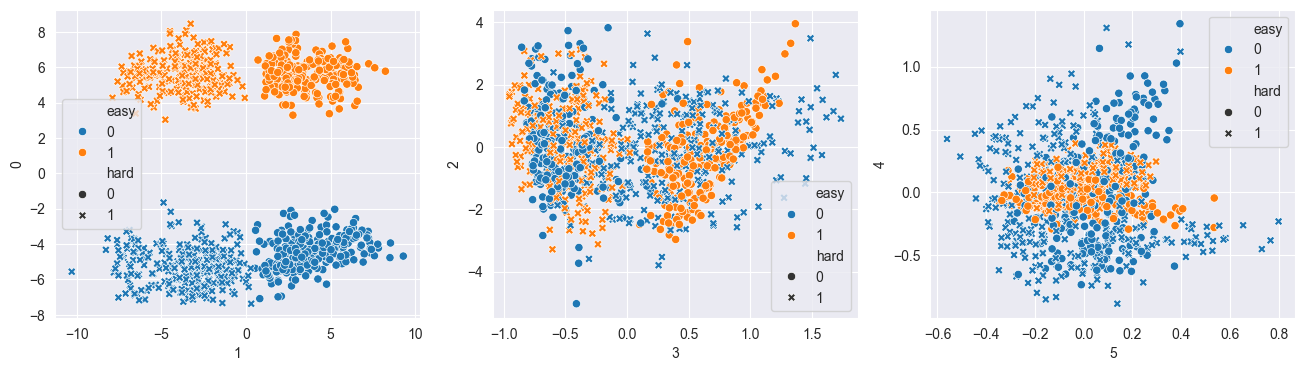

In [116]:
fig, axs = plt.subplots(ncols=3, figsize=(16,4))
sns.scatterplot(data=d,x=1,y=0,hue='easy',style='hard',ax=axs[0])
sns.scatterplot(data=d,x=3,y=2,hue='easy',style='hard',ax=axs[1])
sns.scatterplot(data=d,x=5,y=4,hue='easy',style='hard',ax=axs[2])
plt.show()

In [120]:
d[[0,1,'easy','hard']]

,0,1,easy,hard
0,5.639267,1.597555,1,0
1,6.178902,-2.718951,1,1
2,-6.195253,-2.936900,0,1
3,-4.497264,7.354367,0,0
4,-6.608449,-3.429374,0,1
...,...,...,...,...
1019,-5.795399,3.527475,0,0
1020,6.186435,-2.979565,1,1
1021,5.215181,3.048831,1,0
1022,6.563657,-2.898109,1,1
